In [4]:
#import sys
#print(sys.executable)

In [ ]:
# download deps through notebook
#import sys
# !{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn

In [6]:
print("hi")

hi


In [9]:
# !py -m pip install kaggle

In [10]:
# !kaggle datasets download -d otto/recsys-dataset -p data --unzip

In [ ]:
# load the data into a pandas dataframe and then do some basic EDA on it. I will start with loading the data into a pandas dataframe.
from pathlib import Path
import json
import pandas as pd

data_dir = Path("data")

def load_jsonl(path, max_rows=10_000):
    rows = []

    with path.open("r", encoding="utf-8") as file:
        for i, line in enumerate(file):
            if i >= max_rows:
                break
            rows.append(json.loads(line))

    return rows

train_rows = load_jsonl(
    data_dir / "otto-recsys-train.jsonl",
    max_rows=10_000
)

test_rows = load_jsonl(
    data_dir / "otto-recsys-test.jsonl",
    max_rows=10_000
)

train_df = pd.DataFrame(train_rows)
test_df = pd.DataFrame(test_rows)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(10000, 2)
(10000, 2)


,session,events
0,0,"[{'aid': 1517085, 'ts': 1659304800025, 'type':..."
1,1,"[{'aid': 424964, 'ts': 1659304800025, 'type': ..."
2,2,"[{'aid': 763743, 'ts': 1659304800038, 'type': ..."
3,3,"[{'aid': 1425967, 'ts': 1659304800095, 'type':..."
4,4,"[{'aid': 613619, 'ts': 1659304800119, 'type': ..."


In [12]:
# Loading the data into a pandas dataframe and then doing some basic EDA on it. I will start with loading the data into a pandas dataframe.
rows2 = []

with open("data/otto-recsys-train.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 10000:
            break
        rows2.append(json.loads(line))  # rows2, not rows

In [14]:
# Exploding the events column in the train_df dataframe. This will create a new row for each event in the events list. I will then normalize the events column and create a new dataframe called events_df. I will also add a new column called session to the events_df dataframe which will contain the session id for each event.
train_exploded = train_df.explode("events", ignore_index=True)

events_df = pd.json_normalize(train_exploded["events"])
events_df["session"] = train_exploded["session"].values

events_df.head()

,aid,ts,type,session
0,1517085,1659304800025,clicks,0
1,1563459,1659304904511,clicks,0
2,1309446,1659367439426,clicks,0
3,16246,1659367719997,clicks,0
4,1781822,1659367871344,clicks,0


In [15]:
events_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 628747 entries, 0 to 628746
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   aid      628747 non-null  int64
 1   ts       628747 non-null  int64
 2   type     628747 non-null  str  
 3   session  628747 non-null  int64
dtypes: int64(3), str(1)
memory usage: 19.2 MB


### No missing values
### int64(aid, ts, session) - string (type)

In [ ]:
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Sessions:", train_df["session"].nunique())
print("Events:", len(events_df))
print("Items:", events_df["aid"].nunique())
print("\nColumns:")
print(events_df.columns.tolist())

events_df.head()

Sessions: 10000
Events: 628747
Items: 187648

Columns:
['aid', 'ts', 'type', 'session']


,aid,ts,type,session
0,1517085,1659304800025,clicks,0
1,1563459,1659304904511,clicks,0
2,1309446,1659367439426,clicks,0
3,16246,1659367719997,clicks,0
4,1781822,1659367871344,clicks,0


In [17]:
# Checking once more for missing values
print(events_df.info())

missing = events_df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

<class 'pandas.DataFrame'>
RangeIndex: 628747 entries, 0 to 628746
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   aid      628747 non-null  int64
 1   ts       628747 non-null  int64
 2   type     628747 non-null  str  
 3   session  628747 non-null  int64
dtypes: int64(3), str(1)
memory usage: 19.2 MB
None


Series([], dtype: int64)

type
clicks    571560
carts      45202
orders     11985
Name: count, dtype: int64


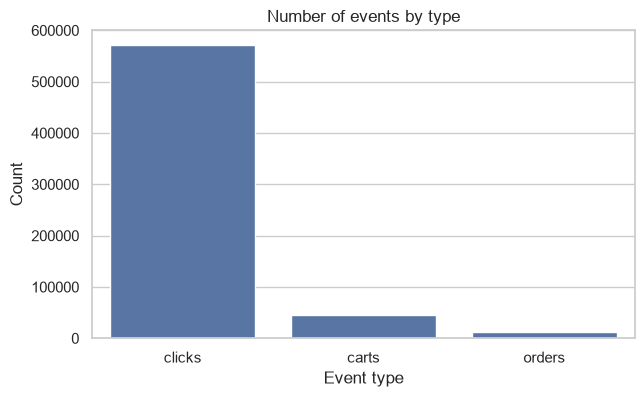

In [ ]:
# Visualizing event counts by type
event_counts = events_df["type"].value_counts()

print(event_counts)

plt.figure(figsize=(7, 4))
sns.barplot(
    x=event_counts.index,
    y=event_counts.values
)
plt.title("Number of events by type")
plt.xlabel("Event type")
plt.ylabel("Count")
plt.show()

count    10000.000000
mean        62.874700
std         85.291679
min          2.000000
25%          8.000000
50%         26.000000
75%         81.000000
max        495.000000
dtype: float64


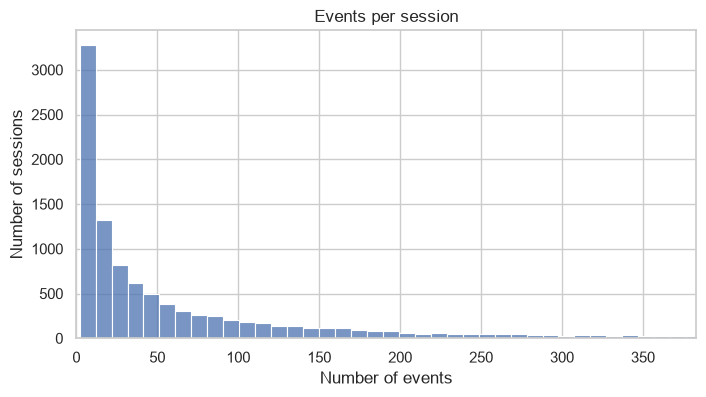

In [ ]:
# Visualizing the number of events per session
events_per_session = events_df.groupby("session").size()

print(events_per_session.describe())

plt.figure(figsize=(8, 4))
sns.histplot(events_per_session, bins=50)
plt.title("Events per session")
plt.xlabel("Number of events")
plt.ylabel("Number of sessions")
plt.xlim(0, events_per_session.quantile(0.99))
plt.show()